# Phase 3 - Modeling

In [103]:
# Load general utilities
# ----------------------
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as ax
import datetime
import numpy as np
import pickle
import time
import seaborn as sns

# Load sklearn utilities
# ----------------------
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, brier_score_loss, mean_squared_error, r2_score

from sklearn.calibration import calibration_curve

# Load classifiers
# ----------------
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import BaggingClassifier

# Other Packages
# --------------
from scipy.stats import kendalltau
from sklearn.neural_network import MLPRegressor
from sklearn import linear_model
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
#from sklearn.externals.six import StringIO  
from IPython.display import Image  
from sklearn.tree import export_graphviz
#from scipy.interpolate import spline

# Load debugger, if required
#import pixiedust
pd.options.mode.chained_assignment = None #'warn'

# suppress all warnings
import warnings
warnings.filterwarnings("ignore")

In [104]:
# Define a function that, given a CVGridSearch object, finds the
# percentage difference between the best and worst scores
def find_score_variation(cv_model):
    all_scores = cv_model.cv_results_['mean_test_score']
    
    return( np.abs((max(all_scores) - min(all_scores))) * 100 / max(all_scores) )
    

# Define a function that checks, given a CVGridSearch object,
# whether the optimal parameters lie on the edge of the search
# grid
def find_opt_params_on_edge(cv_model):
    out = False
    
    for i in cv_model.param_grid:
        if cv_model.best_params_[i] in [ cv_model.param_grid[i][0], cv_model.param_grid[i][-1] ]:
            out = True
            break
            
    return out

## Define a default random seed and an output file

In [105]:
default_seed = 1
output_file = "output_sample"

In [106]:
def dump_to_output(key, value):
    with open(output_file, "a") as f:
        f.write(",".join([str(default_seed), key, str(value)]) + "\n")

## Load the data and engineer the features

In [107]:
# Read the data and features
data, discrete_features, continuous_features, ret_cols =pickle.load(open("../Phase2/phase2_op.pickle", "rb" ) )

In [108]:
data.loan_status.value_counts()

loan_status
Fully Paid                                             887759
Charged Off                                            233762
Late (31-120 days)                                      33661
In Grace Period                                         19490
Late (16-30 days)                                        9006
Default                                                   937
Does not meet the credit policy. Status:Fully Paid        655
Does not meet the credit policy. Status:Charged Off       262
Name: count, dtype: int64

In [109]:
## Create the outcome columns
data['outcome'] = data['loan_status'].isin([
    'Charged Off',
    'Default', 
    'Does not meet the credit policy. Status:Charged Off'
])

In [110]:
print(f"Default rate: {data['outcome'].mean():.1%}")
print(f"Defaults: {data['outcome'].sum():,}")

Default rate: 19.8%
Defaults: 234,961


In [111]:
# Create a feature for the length of a person's credit history at the time the loan is issued
data['cr_hist'] = (data.issue_d - data.earliest_cr_line).dt.days / 30.4375
continuous_features.append('cr_hist')

In [112]:
# Randomly assign each row to a training and test set. We do this now because we will be fitting a variety of models on various time periods, and we would like every period to use the *same* training/test split
np.random.seed(default_seed)
## create the train columns where the value is True if it is a train instance and False otherwise
data['train']=np.random.choice([True, False], size=len(data), p=[0.7,0.3])

In [113]:
data.groupby(['outcome']).agg({'train':'sum'}).reset_index()

,outcome,train
0,False,665755
1,True,164404


In [114]:
print(f"Train size: {data['train'].sum():,}")
print(f"Test size: {(~data['train']).sum():,}")
print(f"Train %: {data['train'].mean():.1%}")

Train size: 830,159
Test size: 355,373
Train %: 70.0%


In [115]:
# Create a matrix of features and outcomes, with dummies. Record the names of the dummies for later use
X_continuous = data[continuous_features].values

X_discrete = pd.get_dummies(data[discrete_features], dummy_na = True, prefix_sep = "::", drop_first = True)
discrete_features_dummies = X_discrete.columns.tolist()
X_discrete = X_discrete.values

X = np.concatenate( (X_continuous, X_discrete), axis = 1 )

y = data.outcome.values

train = data.train.values

In [116]:
print(X.shape)

(1185532, 178)


## Prepare functions to fit and evaluate models

In [117]:
def prepare_data(data_subset = np.array([True]*len(data)),
                    n_samples_train = 100000,
                    n_samples_test = 30000,
                    feature_subset = None,
                    date_range_train = (data.issue_d.min(), data.issue_d.max()),
                    date_range_test = (data.issue_d.min(), data.issue_d.max()),
                    random_state = default_seed):
    '''
    This function will prepare the data for classification or regression.
    It expects the following parameters:
      - data_subset: a numpy array with as many entries as rows in the
                     dataset. Each entry should be True if that row
                     should be used, or False if it should be ignored
      - n_samples_train: the total number of samples to be used for training.
                         Will trigger an error if this number is larger than
                         the number of rows available after all filters have
                         been applied
      - n_samples_test: as above for testing
      - feature_subect: A list containing the names of the features to be
                        used in the model. In None, all features in X are
                        used
      - date_range_train: a tuple containing two dates. All rows with loans
                          issued outside of these two dates will be ignored in
                          training
      - date_range_test: as above for testing
      - random_state: the random seed to use when selecting a subset of rows
      
    Note that this function assumes the data has a "Train" column, and will
    select all training rows from the rows with "True" in that column, and all
    the testing rows from those with a "False" in that column.
    
    This function returns a dictionary with the following entries
      - X_train: the matrix of training data
      - y_train: the array of training labels
      - train_set: a Boolean vector with as many entries as rows in the data
                  that denotes the rows that were used in the train set
      - X_test: the matrix of testing data
      - y_test: the array of testing labels
      - test_set: a Boolean vector with as many entries as rows in the data
                  that denotes the rows that were used in the test set
    '''
    
    np.random.seed(random_state)
        
    # Filter down the data to the required date range, and downsample
    # as required
    filter_train = ( train & (data.issue_d >= date_range_train[0]) &
                            (data.issue_d <= date_range_train[1]) & data_subset ).values
    filter_test = ( (train == False) & (data.issue_d >= date_range_test[0])
                            & (data.issue_d <= date_range_test[1]) & data_subset ).values
    
    filter_train[ np.random.choice( np.where(filter_train)[0], size = filter_train.sum()
                                                   - n_samples_train, replace = False ) ] = False
    filter_test[ np.random.choice( np.where(filter_test)[0], size = filter_test.sum()
                                                   - n_samples_test, replace = False ) ] = False
    
    # Prepare the training and test set
    X_train = X[ filter_train , :]
    X_test = X[ filter_test, :]
    if feature_subset != None:
        cols = [i for i, j in enumerate(continuous_features + discrete_features_dummies)
                                                     if j.split("::")[0] in feature_subset]
        X_train = X_train[ : , cols ]
        X_test = X_test[ : , cols ]
        
    y_train = y[ filter_train ]
    y_test = y[ filter_test ]
    
    # Scale the variables
    scaler = preprocessing.MinMaxScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    
    # return training and testing data
    out = {'X_train':X_train, 'y_train':y_train, 'train_set':filter_train, 
           'X_test':X_test, 'y_test':y_test, 'test_set':filter_test}
    
    return out

In [118]:
def fit_classification(model, data_dict,
                          cv_parameters = {},
                          model_name = None,
                          random_state = default_seed,
                          output_to_file = True,
                          print_to_screen = True):
    '''
    This function will fit a classification model to data and print various evaluation
    measures. It expects the following parameters
      - model: an sklearn model object
      - data_dict: the dictionary containing both training and testing data;
                   returned by the prepare_data function
      - cv_parameters: a dictionary of parameters that should be optimized
                       over using cross-validation. Specifically, each named
                       entry in the dictionary should correspond to a parameter,
                       and each element should be a list containing the values
                       to optimize over
      - model_name: the name of the model being fit, for printouts
      - random_state: the random seed to use
      - output_to_file: if the results will be saved to the output file
      - print_to_screen: if the results will be printed on screen
    
    If the model provided does not have a predict_proba function, we will
    simply print accuracy diagnostics and return.
    
    If the model provided does have a predict_proba function, we first
    figure out the optimal threshold that maximizes the accuracy and
    print out accuracy diagnostics. We then print an ROC curve, sensitivity/
    specificity curve, and calibration curve.
    
    This function returns a dictionary with the following entries
      - model: the best fitted model
      - y_pred: predictions for the test set
      - y_pred_probs: probability predictions for the test set, if the model
                      supports them
      - y_pred_score: prediction scores for the test set, if the model does not 
                      output probabilities.
    '''
        
    np.random.seed(random_state)
    
    # --------------------------
    #   Step 1 - Load the data
    # --------------------------
    X_train = data_dict['X_train']
    y_train = data_dict['y_train']
    
    X_test = data_dict['X_test']
    y_test = data_dict['y_test']
    
    filter_train = data_dict['train_set']    
  
    # --------------------------
    #   Step 2 - Fit the model
    # --------------------------

    cv_model = GridSearchCV(model, cv_parameters, n_jobs=-1)
    
    start_time = time.time()
    cv_model.fit(X_train, y_train)
    end_time = time.time()
    
    best_model = cv_model.best_estimator_
    
    if print_to_screen:

        if model_name != None:
            print("=========================================================")
            print("  Model: " + model_name)
            print("=========================================================")

        print("Fit time: " + str(round(end_time - start_time, 2)) + " seconds")
        print("Optimal parameters:")
        print(cv_model.best_params_)
        print("")
    
    # -------------------------------
    #   Step 3 - Evaluate the model
    # -------------------------------
    
    # If possible, make probability predictions
    try:
        y_pred_probs = best_model.predict_proba(X_test)[:,1]
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
        
        probs_predicted = True
    except:
        probs_predicted = False
    
    # Make predictions; if we were able to find probabilities, use
    # the threshold that maximizes the accuracy in the training set.
    # If not, just use the learner's predict function
    if probs_predicted:
        y_train_pred_probs = best_model.predict_proba(X_train)[:,1]
        fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_pred_probs)
        
        true_pos_train = tpr_train*(y_train.sum())
        true_neg_train = (1 - fpr_train) *(1-y_train).sum()
        
        best_threshold_index = np.argmax(true_pos_train + true_neg_train)
        best_threshold = 1 if best_threshold_index == 0 else thresholds_train[ best_threshold_index ]
        
        if print_to_screen:
            print("Accuracy-maximizing threshold was: " + str(best_threshold))
        
        y_pred = (y_pred_probs > best_threshold)
    else:
        y_pred = best_model.predict(X_test)
    
    if print_to_screen:
        print("Accuracy: ", accuracy_score(y_test, y_pred))
        print(classification_report(y_test, y_pred, target_names =['No default', 'Default'], digits = 4))

    if print_to_screen:
        if probs_predicted:        
            plt.figure(figsize = (13, 4.5))
            plt.subplot(2, 2, 1)

            plt.title("ROC Curve (AUC = %0.2f)"% roc_auc_score(y_test, y_pred_probs))
            plt.plot(fpr, tpr, 'b')
            plt.plot([0,1],[0,1],'r--')
            plt.xlim([0,1]); plt.ylim([0,1])
            plt.ylabel('True Positive Rate')
            plt.xlabel('False Positive Rate')

            plt.subplot(2, 2, 3)

            plt.plot(thresholds, tpr, 'b', label = 'Sensitivity')
            plt.plot(thresholds, 1 -fpr, 'r', label = 'Specificity')
            plt.legend(loc = 'lower right')
            plt.xlim([0,1]); plt.ylim([0,1])
            plt.xlabel('Threshold')

            plt.subplot(2, 2, 2)

            fp_0, mpv_0 = calibration_curve(y_test, y_pred_probs, n_bins = 10)
            plt.plot([0,1], [0,1], 'k:', label='Perfectly calibrated')
            plt.plot(mpv_0, fp_0, 's-')
            plt.ylabel('Fraction of Positives')
            plt.xlim([0,1]); plt.ylim([0,1])
            plt.legend(loc ='upper left')
            
            plt.subplot(2, 2, 4)
            plt.hist(y_pred_probs, range=(0, 1), bins=10, histtype="step", lw=2)
            plt.xlim([0,1]); plt.ylim([0,20000])
            plt.xlabel('Mean Predicted Probability')
            plt.ylabel('Count')
            
            #plt.tight_layout()
            plt.show()
        
    # Additional Score Check
    if probs_predicted:
        y_train_score = y_train_pred_probs
    else:
        y_train_score = best_model.decision_function(X_train)
        
    tau, p_value = kendalltau(y_train_score, data.grade[filter_train])
    if print_to_screen:
        print("")
        print("Similarity to LC grade ranking: ", tau)
    
    if probs_predicted:
        brier_score = brier_score_loss(y_test, y_pred_probs)
        if print_to_screen:
            print("Brier score:", brier_score)
    
    # Return the model predictions, and the
    # test set
    # -------------------------------------
    out = {'model':best_model, 'y_pred_labels':y_pred}
    
    if probs_predicted:
        out.update({'y_pred_probs':y_pred_probs})
    else:
        y_pred_score = best_model.decision_function(X_test)
        out.update({'y_pred_score':y_pred_score})
        
    # Output results to file
    # ----------------------
    if probs_predicted and output_to_file:
        # Check whether y of the CV parameters are on the edge of
        # the search space
        opt_params_on_edge = find_opt_params_on_edge(cv_model)
        dump_to_output(model_name + "::search_on_edge", opt_params_on_edge)
        if print_to_screen:
            print("Were parameters on edge? : " + str(opt_params_on_edge))
        
        # Find out how different the scores are for the different values
        # tested for by cross-validation. If they're not too different, then
        # even if the parameters are off the edge of the search grid, we should
        # be ok
        score_variation = find_score_variation(cv_model)
        dump_to_output(model_name + "::score_variation", score_variation)
        if print_to_screen:
            print("Score variations around CV search grid : " + str(score_variation))
        
        # Print out all the scores
        dump_to_output(model_name + "::all_cv_scores", str(cv_model.cv_results_['mean_test_score']))
        if print_to_screen:
            print( str(cv_model.cv_results_['mean_test_score']) )
        
        # Dump the AUC to file
        dump_to_output(model_name + "::roc_auc", roc_auc_score(y_test, y_pred_probs) )
        
    return out

## Train and Test different ML classification models


In [119]:
your_features = [
    'loan_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade',
    'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
    'purpose', 'dti', 'delinq_2yrs', 'cr_hist',
    'open_acc', 'pub_rec', 'fico_range_low',
    'revol_bal', 'revol_util', 'inq_last_6mths',
    'pub_rec_bankruptcies', 'total_acc', 'addr_state',
    'acc_now_delinq', 'acc_open_past_24mths', 'avg_cur_bal',
    'bc_open_to_buy', 'delinq_amnt', 'mo_sin_old_rev_tl_op',
    'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc',
    'mths_since_recent_inq', 'num_accts_ever_120_pd',
    'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats',
    'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts',
    'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'tax_liens',
    'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
    'total_il_high_credit_limit', 'total_rev_hi_lim',
    'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m',
    'num_tl_120dpd_2m', 'num_bc_sats', 'num_sats' if 'num_sats' in continuous_features else 'num_bc_sats'
]

data_dict = prepare_data(feature_subset=your_features)
print("Data prepared successfully")

all_features = pd.Series(continuous_features + discrete_features_dummies)
idx = [i for i, j in enumerate(continuous_features + discrete_features_dummies)
                                                     if j.split("::")[0] in your_features]
selected_features = all_features[idx]
selected_features.reset_index(drop=True,inplace=True)

Data prepared successfully


In [120]:
print(len(selected_features))

174


### Naive Bayes

In [121]:
import time

  Model: Naive Bayes
Fit time: 4.09 seconds
Optimal parameters:
{}

Accuracy-maximizing threshold was: 1
Accuracy:  0.8008666666666666
              precision    recall  f1-score   support

  No default     0.8009    1.0000    0.8894     24026
     Default     0.0000    0.0000    0.0000      5974

    accuracy                         0.8009     30000
   macro avg     0.4004    0.5000    0.4447     30000
weighted avg     0.6414    0.8009    0.7123     30000



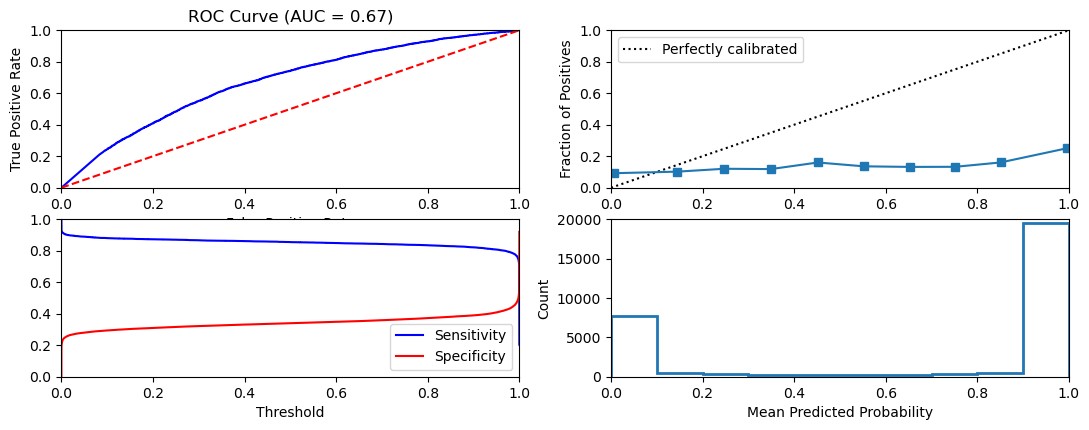


Similarity to LC grade ranking:  0.7180820491134229
Brier score: 0.5363865811947777
Were parameters on edge? : False
Score variations around CV search grid : 0.0
[0.49901]
Total time: 0.1 minutes


In [122]:
start = time.time()
gnb = GaussianNB()
gnb_result = fit_classification(model=gnb, data_dict=data_dict, model_name="Naive Bayes")
print(f"Total time: {(time.time()-start)/60:.1f} minutes")

### $l_1$ regularized logistic regression

  Model: L1 Logistic Regression
Fit time: 587.08 seconds
Optimal parameters:
{'C': 0.1}

Accuracy-maximizing threshold was: 0.5235910072483514
Accuracy:  0.804
              precision    recall  f1-score   support

  No default     0.8062    0.9942    0.8904     24026
     Default     0.6263    0.0390    0.0734      5974

    accuracy                         0.8040     30000
   macro avg     0.7163    0.5166    0.4819     30000
weighted avg     0.7704    0.8040    0.7277     30000



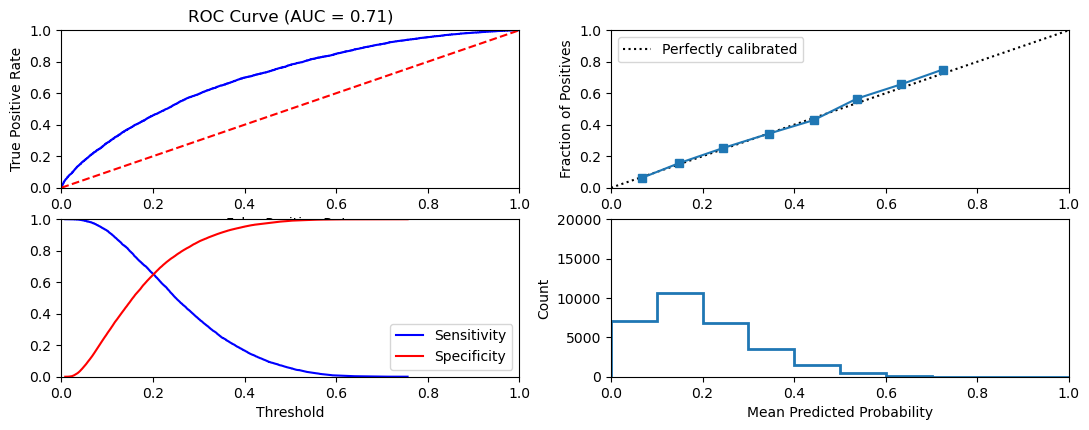


Similarity to LC grade ranking:  0.681878919752427
Brier score: 0.14544583695886962
Were parameters on edge? : False
Score variations around CV search grid : 0.21385055327612
[0.80258 0.80308 0.8043  0.80385 0.80389 0.80379]
Total time: 9.8 minutes


In [129]:
## Train and test a l_1 regularized logistic regression classifier
start = time.time()
# L1 Logistic Regression
l1_logistic = LogisticRegression(penalty='l1', solver='liblinear', random_state=default_seed)
cv_parameters = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
l1_logistic = fit_classification(model=l1_logistic, data_dict=data_dict, 
                               cv_parameters=cv_parameters, model_name="L1 Logistic Regression")
print(f"Total time: {(time.time()-start)/60:.1f} minutes")

### $l_2$ regularized logistic regression

/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logis

/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logis

  Model: L2 Logistic Regression
Fit time: 45.86 seconds
Optimal parameters:
{'C': 0.1}

Accuracy-maximizing threshold was: 0.5365907008478444
Accuracy:  0.8031
              precision    recall  f1-score   support

  No default     0.8053    0.9945    0.8900     24026
     Default     0.6018    0.0331    0.0628      5974

    accuracy                         0.8031     30000
   macro avg     0.7036    0.5138    0.4764     30000
weighted avg     0.7648    0.8031    0.7253     30000



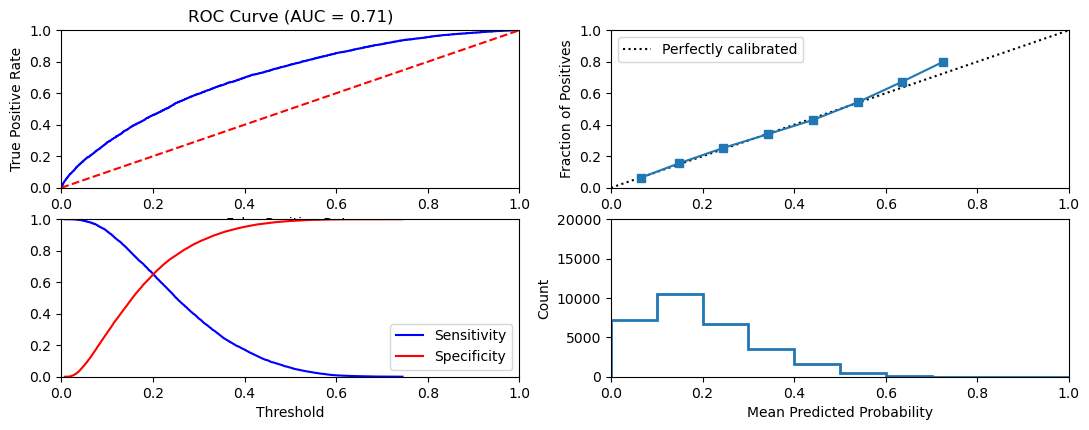


Similarity to LC grade ranking:  0.6705427854074041
Brier score: 0.14532137087491764
Were parameters on edge? : False
Score variations around CV search grid : 0.16787703939515436
[0.80281 0.80358 0.80416 0.80384 0.8037  0.80368]
Total time: 0.8 minutes


In [130]:
## Train and test a l_2 regularized logistic regression classifier
start = time.time()
# L2 Logistic Regression
l2_logistic = LogisticRegression(penalty='l2', solver='lbfgs', random_state=default_seed)
cv_parameters = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
l2_logistic = fit_classification(model=l2_logistic, data_dict=data_dict, 
                               cv_parameters=cv_parameters, model_name="L2 Logistic Regression")
print(f"Total time: {(time.time()-start)/60:.1f} minutes")

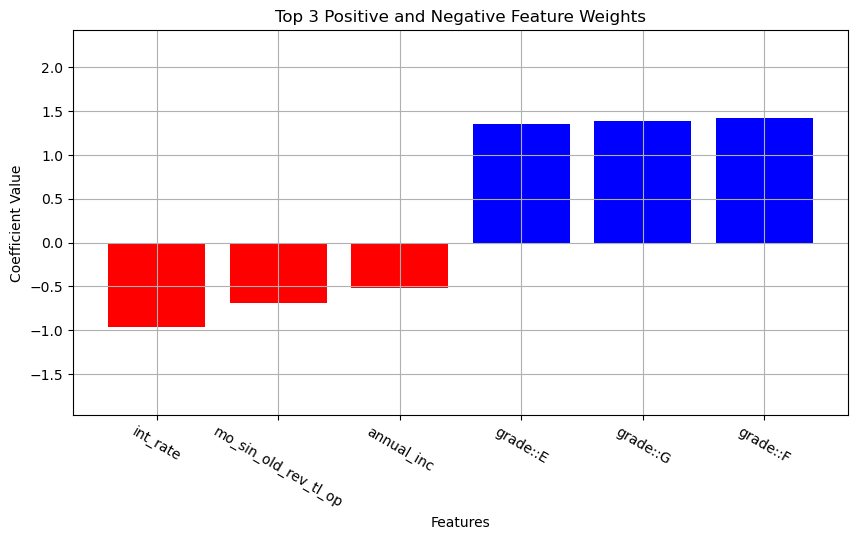

In [131]:
model_coefs = l2_logistic['model'].coef_[0]  # Get the coefficients from the model

# Find indices of the top 3 positive and negative weights
top_and_bottom_idx = list(np.argsort(model_coefs)[:3]) + list(np.argsort(model_coefs)[-3:])
bplot = pd.Series(model_coefs[top_and_bottom_idx])

# Corresponding feature names for the x-axis
xticks = selected_features[top_and_bottom_idx].tolist()

# Create bar plot
plt.figure(figsize=(10, 5))
plt.bar(xticks, bplot, color=['red' if x < 0 else 'blue' for x in bplot])
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.title('Top 3 Positive and Negative Feature Weights')
plt.xticks(rotation=-30)
plt.ylim([min(bplot) - 1, max(bplot) + 1])  # Adjust ylim to give some space
plt.grid(True)
plt.show()

### Decision tree

  Model: Decision Tree
Fit time: 51.32 seconds
Optimal parameters:
{'max_depth': 10}

Accuracy-maximizing threshold was: 0.5176470588235295
Accuracy:  0.7917
              precision    recall  f1-score   support

  No default     0.8114    0.9640    0.8811     24026
     Default     0.4056    0.0989    0.1591      5974

    accuracy                         0.7917     30000
   macro avg     0.6085    0.5314    0.5201     30000
weighted avg     0.7306    0.7917    0.7373     30000



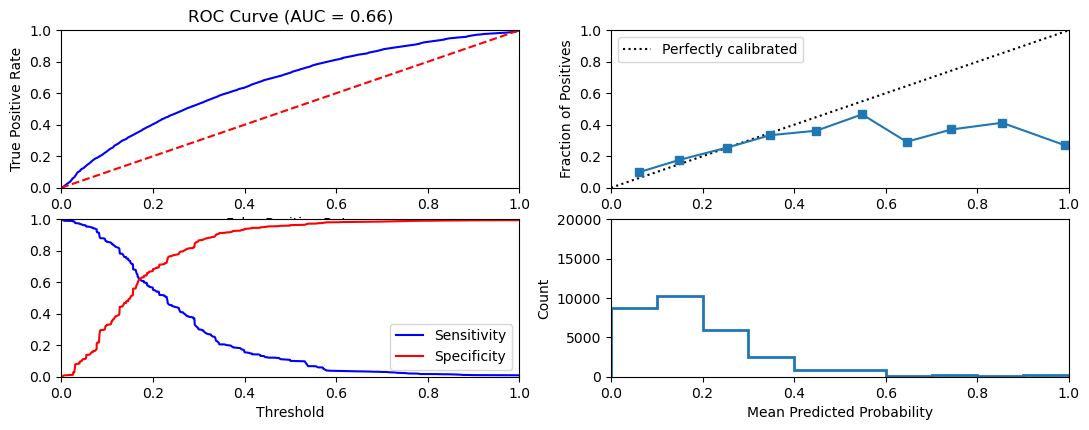


Similarity to LC grade ranking:  0.6109797632670297
Brier score: 0.15787687090849253
Were parameters on edge? : False
Score variations around CV search grid : 12.011065362840974
[0.68385 0.7772  0.71347 0.68849 0.68413 0.68385]
Total time: 0.9 minutes


In [132]:
## Train and test a decision tree classifier
start=time.time()
decision_tree = DecisionTreeClassifier(random_state=default_seed)
cv_parameters = {'max_depth': [None, 10, 20, 30, 40, 50]}
dt_result = fit_classification(model=decision_tree, data_dict=data_dict,
                               cv_parameters=cv_parameters, model_name="Decision Tree")
print(f"Total time: {(time.time()-start)/60:.1f} minutes")

### Random forest

  Model: Random Forest
Fit time: 677.93 seconds
Optimal parameters:
{'max_depth': 30, 'max_features': 'sqrt', 'n_estimators': 150}

Accuracy-maximizing threshold was: 0.3865316390244693
Accuracy:  0.7932
              precision    recall  f1-score   support

  No default     0.8204    0.9497    0.8803     24026
     Default     0.4474    0.1637    0.2397      5974

    accuracy                         0.7932     30000
   macro avg     0.6339    0.5567    0.5600     30000
weighted avg     0.7461    0.7932    0.7528     30000



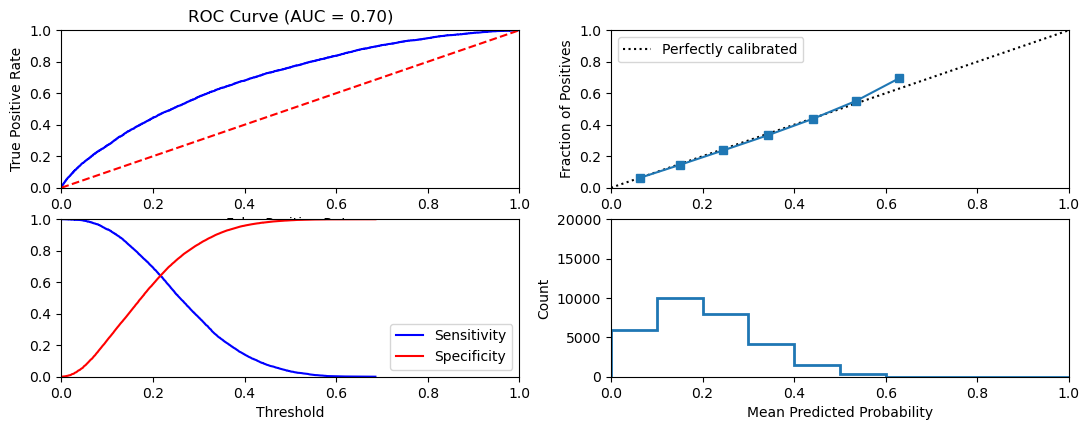


Similarity to LC grade ranking:  0.5259047681962002
Brier score: 0.14701084206105008
Were parameters on edge? : True
Score variations around CV search grid : 0.1655381858010345
[0.80211 0.80294 0.80321 0.8024  0.80301 0.80294 0.80258 0.80258 0.80258
 0.80258 0.80258 0.80258 0.80261 0.80262 0.80267 0.80259 0.80259 0.80258
 0.80281 0.80307 0.80339 0.80291 0.80294 0.80297 0.8023  0.80272 0.80344
 0.80229 0.80295 0.80316]
Total time: 11.3 minutes


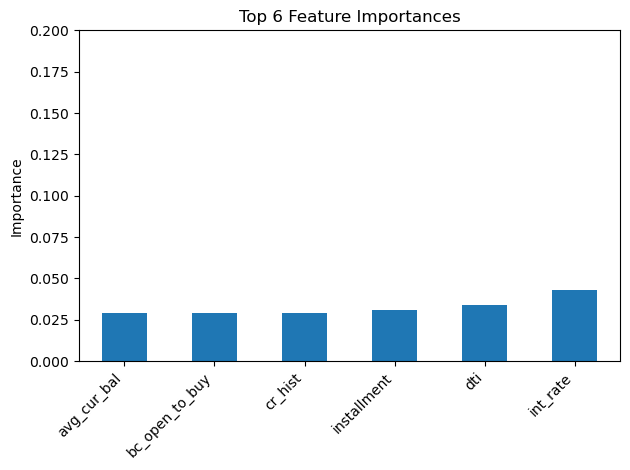

In [133]:
start = time.time()

random_forest = RandomForestClassifier(random_state=default_seed, n_jobs=-1)
cv_parameters = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

rf_result = fit_classification(
    model=random_forest,
    data_dict=data_dict,
    cv_parameters=cv_parameters,
    model_name="Random Forest"
)

print(f"Total time: {(time.time()-start)/60:.1f} minutes")

# get the fitted model from the result object
rf_model = rf_result['model']   # or rf_result["best_model"], depending on your function

feature_importances = rf_model.feature_importances_
top_idx = np.argsort(feature_importances)[-6:]

bplot = pd.Series(feature_importances[top_idx], index=selected_features[top_idx])

ax = bplot.plot(kind='bar', ylim=(0, 0.2))
ax.set_xticklabels(bplot.index, rotation=45, ha='right')
plt.title('Top 6 Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### Multi-layer perceptron

/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sushanth/anaconda

  Model: Multi-layer Perceptron
Fit time: 1056.21 seconds
Optimal parameters:
{'activation': 'logistic', 'hidden_layer_sizes': (100,), 'solver': 'sgd'}

Accuracy-maximizing threshold was: 0.5014602280279521
Accuracy:  0.8028
              precision    recall  f1-score   support

  No default     0.8062    0.9923    0.8896     24026
     Default     0.5674    0.0408    0.0762      5974

    accuracy                         0.8028     30000
   macro avg     0.6868    0.5166    0.4829     30000
weighted avg     0.7587    0.8028    0.7276     30000



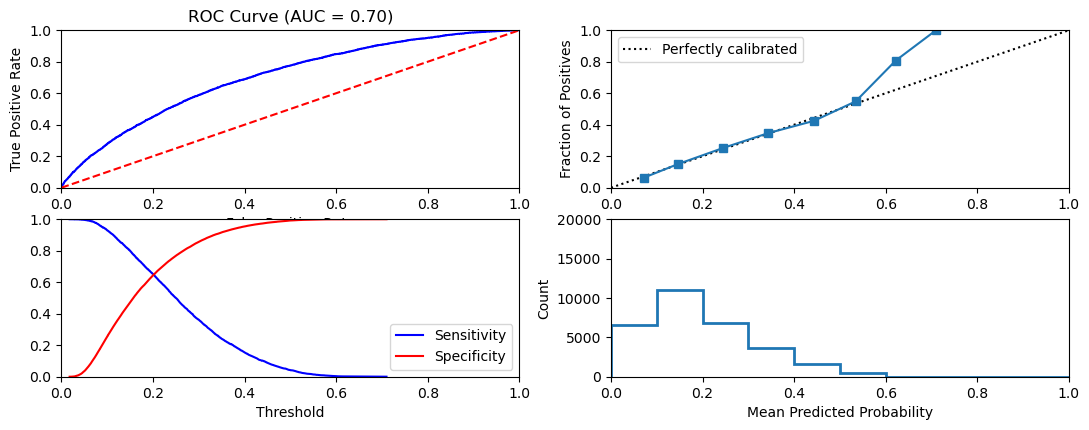


Similarity to LC grade ranking:  0.692372414882335
Brier score: 0.14625754887117148
Were parameters on edge? : True
Score variations around CV search grid : 6.599723767217885
[0.80367 0.78766 0.80258 0.7868  0.8034  0.75063 0.80367 0.75295]


In [134]:
## Train and test a multi-layer perceptron classifier

mlp = MLPClassifier(random_state=default_seed)

cv_parameters = {'hidden_layer_sizes': [(100,), (50, 50)],
                 'activation': ['logistic', 'relu'],
                 'solver': ['sgd', 'adam']}

mlp_result = fit_classification(model=mlp, data_dict=data_dict,
                                 cv_parameters=cv_parameters, model_name="Multi-layer Perceptron")

## Train and Test logistic regression model with features derived by LendingClub

  Model: LogReg L1 with LendingClub Feature 
Fit time: 2.87 seconds
Optimal parameters:
{'C': 0.001}

Accuracy-maximizing threshold was: 1
Accuracy:  0.8008666666666666
              precision    recall  f1-score   support

  No default     0.8009    1.0000    0.8894     24026
     Default     0.0000    0.0000    0.0000      5974

    accuracy                         0.8009     30000
   macro avg     0.4004    0.5000    0.4447     30000
weighted avg     0.6414    0.8009    0.7123     30000



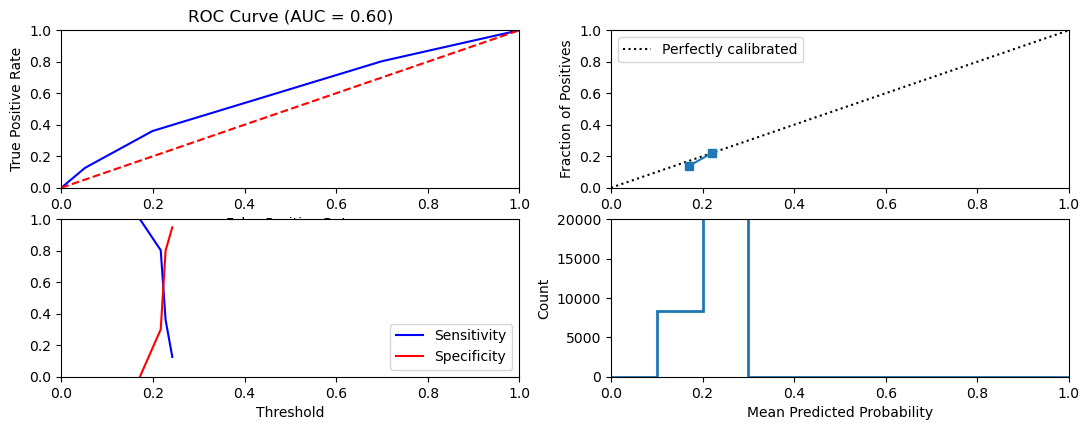


Similarity to LC grade ranking:  0.5931202740621865
Brier score: 0.15771115899629537
Were parameters on edge? : True
Score variations around CV search grid : 0.0
[0.80258 0.80258 0.80258 0.80258 0.80258 0.80258]


In [135]:
## Find a lendingClub-defined feature and train a l1-regularized logistic regression model on data with only that feature
a_lendingclub_feature = ['grade']

data_dict = prepare_data(feature_subset = a_lendingclub_feature)
lc1_only_logistic = LogisticRegression(penalty='l1', solver='liblinear', random_state=default_seed)
cv_parameters = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

lc1_only_logistic = fit_classification(model= lc1_only_logistic, data_dict=data_dict, cv_parameters=cv_parameters, model_name="LogReg L1 with LendingClub Feature ")

  Model: LogReg L2 with LendingClub Feature 
Fit time: 1.09 seconds
Optimal parameters:
{'C': 0.001}

Accuracy-maximizing threshold was: 1
Accuracy:  0.8008666666666666
              precision    recall  f1-score   support

  No default     0.8009    1.0000    0.8894     24026
     Default     0.0000    0.0000    0.0000      5974

    accuracy                         0.8009     30000
   macro avg     0.4004    0.5000    0.4447     30000
weighted avg     0.6414    0.8009    0.7123     30000



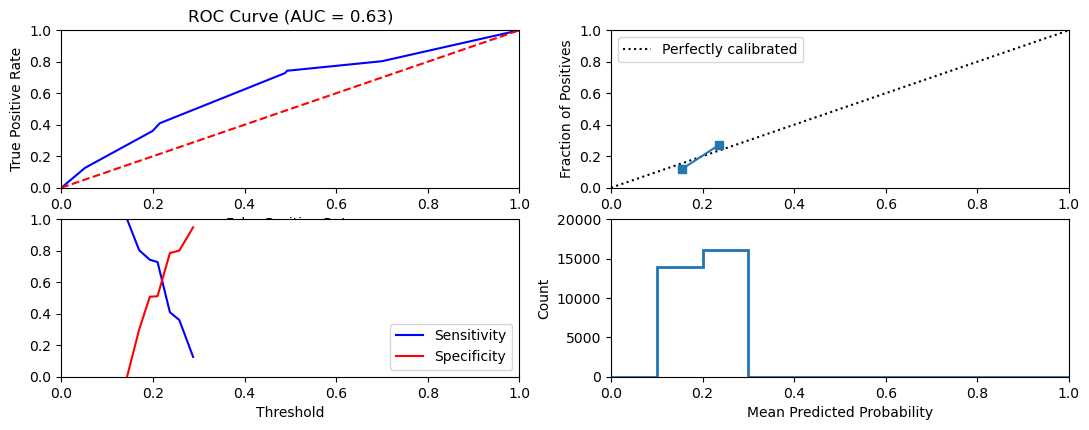


Similarity to LC grade ranking:  0.6956907051503537
Brier score: 0.1541880994027687
Were parameters on edge? : True
Score variations around CV search grid : 0.0
[0.80258 0.80258 0.80258 0.80258 0.80258 0.80258]


In [136]:
## train a l2-regularized logistic regression model on data with only that feature
lc2_only_logistic = LogisticRegression(penalty='l2', solver='lbfgs', random_state=default_seed)
cv_parameters = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

lc2_only_logistic = fit_classification(model= lc2_only_logistic, data_dict=data_dict, cv_parameters=cv_parameters, model_name="LogReg L2 with LendingClub Feature ")


## Train and test all the models you have tried previously after removing features derived by LendingClub 

### Decision tree

  Model: Decision Tree
Fit time: 0.51 seconds
Optimal parameters:
{'max_depth': None}

Accuracy-maximizing threshold was: 1
Accuracy:  0.8008666666666666
              precision    recall  f1-score   support

  No default     0.8009    1.0000    0.8894     24026
     Default     0.0000    0.0000    0.0000      5974

    accuracy                         0.8009     30000
   macro avg     0.4004    0.5000    0.4447     30000
weighted avg     0.6414    0.8009    0.7123     30000



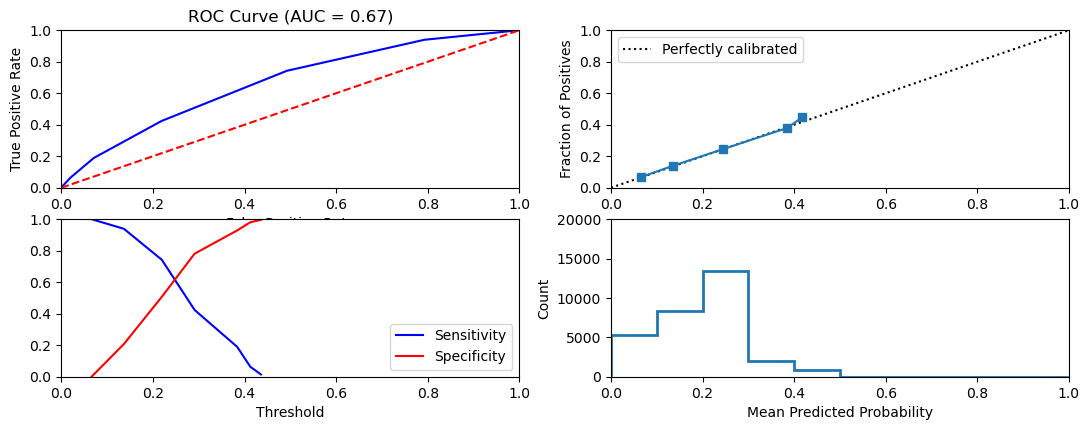


Similarity to LC grade ranking:  1.0
Brier score: 0.15028254936101867
Were parameters on edge? : True
Score variations around CV search grid : 0.0
[0.80258 0.80258 0.80258 0.80258 0.80258 0.80258]
Total time: 0.0 minutes


In [137]:
## Train and test a decision tree classifier
start=time.time()
decision_tree = DecisionTreeClassifier(random_state=default_seed)
cv_parameters = {'max_depth': [None, 10, 20, 30, 40, 50]}
dt_result = fit_classification(model=decision_tree, data_dict=data_dict,
                               cv_parameters=cv_parameters, model_name="Decision Tree")
print(f"Total time: {(time.time()-start)/60:.1f} minutes")

### Random forest

  Model: Random Forest
Fit time: 61.04 seconds
Optimal parameters:
{'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 50}

Accuracy-maximizing threshold was: 1
Accuracy:  0.8008666666666666
              precision    recall  f1-score   support

  No default     0.8009    1.0000    0.8894     24026
     Default     0.0000    0.0000    0.0000      5974

    accuracy                         0.8009     30000
   macro avg     0.4004    0.5000    0.4447     30000
weighted avg     0.6414    0.8009    0.7123     30000



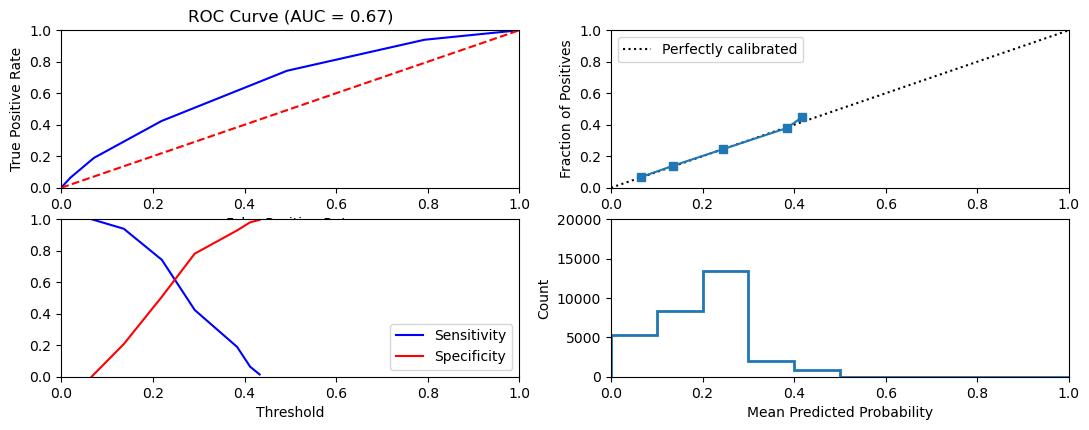


Similarity to LC grade ranking:  1.0
Brier score: 0.15028488861844425
Were parameters on edge? : True
Score variations around CV search grid : 0.0
[0.80258 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258
 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258
 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258 0.80258
 0.80258 0.80258 0.80258]
Total time: 1.0 minutes


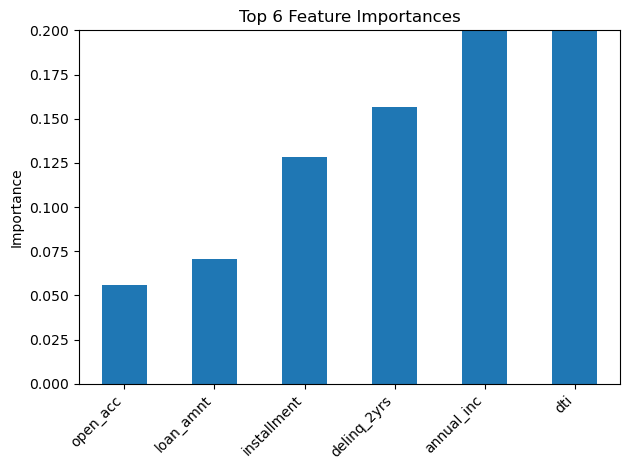

In [138]:
start = time.time()

random_forest = RandomForestClassifier(random_state=default_seed, n_jobs=-1)
cv_parameters = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

rf_result = fit_classification(
    model=random_forest,
    data_dict=data_dict,
    cv_parameters=cv_parameters,
    model_name="Random Forest"
)

print(f"Total time: {(time.time()-start)/60:.1f} minutes")

# get the fitted model from the result object
rf_model = rf_result['model']   # or rf_result["best_model"], depending on your function

feature_importances = rf_model.feature_importances_
top_idx = np.argsort(feature_importances)[-6:]

bplot = pd.Series(feature_importances[top_idx], index=selected_features[top_idx])

ax = bplot.plot(kind='bar', ylim=(0, 0.2))
ax.set_xticklabels(bplot.index, rotation=45, ha='right')
plt.title('Top 6 Feature Importances')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### Multi-layer perceptron

/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sushanth/anaconda3/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/sushanth/anaconda

  Model: Multi-layer Perceptron
Fit time: 1056.21 seconds
Optimal parameters:
{'activation': 'logistic', 'hidden_layer_sizes': (100,), 'solver': 'sgd'}

Accuracy-maximizing threshold was: 0.5014602280279521
Accuracy:  0.8028
              precision    recall  f1-score   support

  No default     0.8062    0.9923    0.8896     24026
     Default     0.5674    0.0408    0.0762      5974

    accuracy                         0.8028     30000
   macro avg     0.6868    0.5166    0.4829     30000
weighted avg     0.7587    0.8028    0.7276     30000



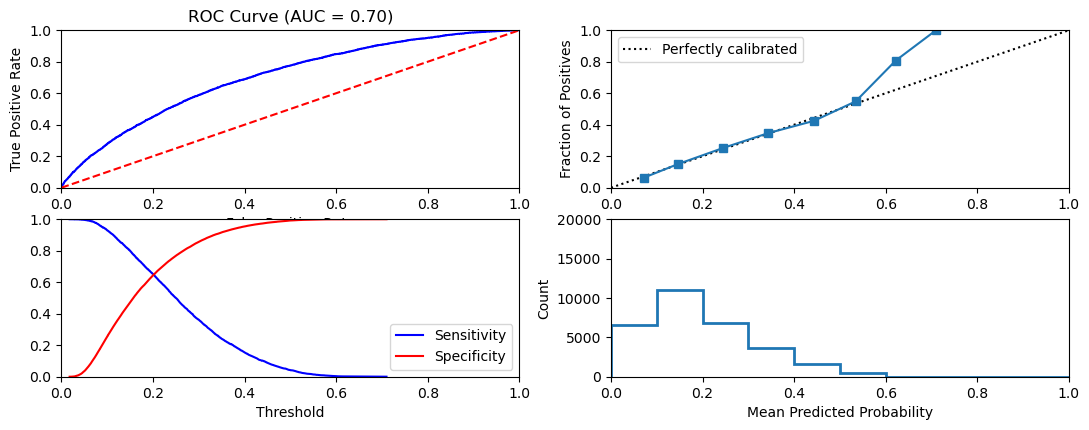


Similarity to LC grade ranking:  0.692372414882335
Brier score: 0.14625754887117148
Were parameters on edge? : True
Score variations around CV search grid : 6.599723767217885
[0.80367 0.78766 0.80258 0.7868  0.8034  0.75063 0.80367 0.75295]


In [134]:
## Train and test a multi-layer perceptron classifier

mlp = MLPClassifier(random_state=default_seed)

cv_parameters = {'hidden_layer_sizes': [(100,), (50, 50)],
                 'activation': ['logistic', 'relu'],
                 'solver': ['sgd', 'adam']}

mlp_result = fit_classification(model=mlp, data_dict=data_dict,
                                 cv_parameters=cv_parameters, model_name="Multi-layer Perceptron")

## Time stability test of MYMODEL

  Model: RF MYMODEL - Time Stability Test
Fit time: 39.07 seconds
Optimal parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}

Accuracy-maximizing threshold was: 0.29535006544370923
Accuracy:  0.7548571428571429
              precision    recall  f1-score   support

  No default     0.8056    0.9017    0.8509      5431
     Default     0.4202    0.2467    0.3108      1569

    accuracy                         0.7549      7000
   macro avg     0.6129    0.5742    0.5809      7000
weighted avg     0.7192    0.7549    0.7299      7000



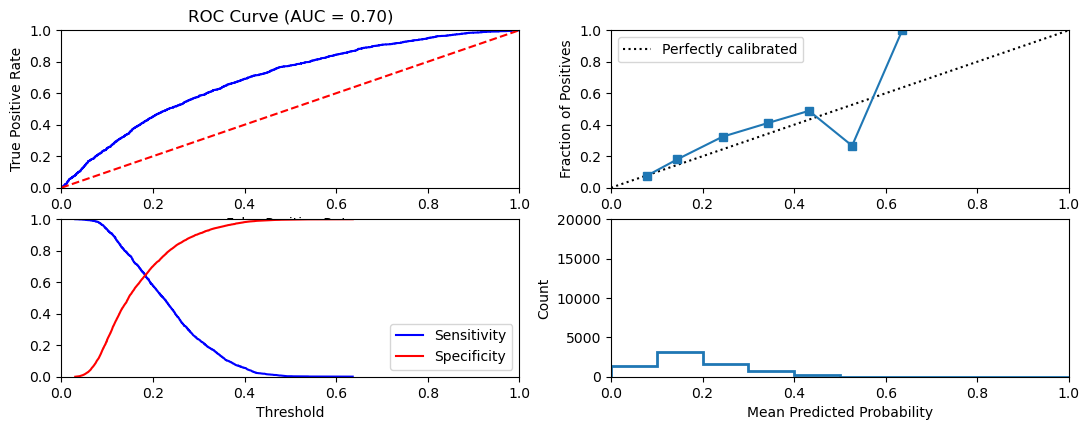


Similarity to LC grade ranking:  0.6576546060489208
Brier score: 0.16278880824205655
Were parameters on edge? : True
Score variations around CV search grid : 0.2022381016583571
[0.82277778 0.823      0.82377778 0.824      0.82366667 0.82366667
 0.82355556 0.82355556 0.82355556 0.82355556 0.82355556 0.82355556
 0.82355556 0.82411111 0.82388889 0.82355556 0.82355556 0.82355556
 0.82244444 0.82322222 0.82333333 0.82366667 0.82388889 0.824
 0.82255556 0.82266667 0.823      0.82311111 0.82344444 0.82288889]


{'model': RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=1),
 'y_pred_labels': array([False, False,  True, ...,  True, False, False]),
 'y_pred_probs': array([0.14305481, 0.06168075, 0.30850364, ..., 0.37994555, 0.22691637,
        0.20108139])}

In [140]:
start_date_train = pd.Timestamp('2010-01-01')
end_date_train   = pd.Timestamp('2014-12-31')
start_date_test  = pd.Timestamp('2015-01-01')
end_date_test    = pd.Timestamp('2017-12-31')

data_dict_test = prepare_data(
    date_range_train=(start_date_train, end_date_train),
    date_range_test=(start_date_test, end_date_test),
    n_samples_train=9000,
    n_samples_test=7000,
    feature_subset=your_features
)

my_model  = RandomForestClassifier(random_state=default_seed, n_jobs=-1)
cv_parameters = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}
fit_classification(model=your_model, data_dict=data_dict_test,
                   cv_parameters=cv_parameters, model_name="RF MYMODEL - Time Stability Test")

## Train and test MYMODEL on the original data

  Model: Random Forest - Full Data
Fit time: 653.93 seconds
Optimal parameters:
{'max_depth': 30, 'max_features': 'sqrt', 'n_estimators': 150}

Accuracy-maximizing threshold was: 0.3865316390244693
Accuracy:  0.7932
              precision    recall  f1-score   support

  No default     0.8204    0.9497    0.8803     24026
     Default     0.4474    0.1637    0.2397      5974

    accuracy                         0.7932     30000
   macro avg     0.6339    0.5567    0.5600     30000
weighted avg     0.7461    0.7932    0.7528     30000



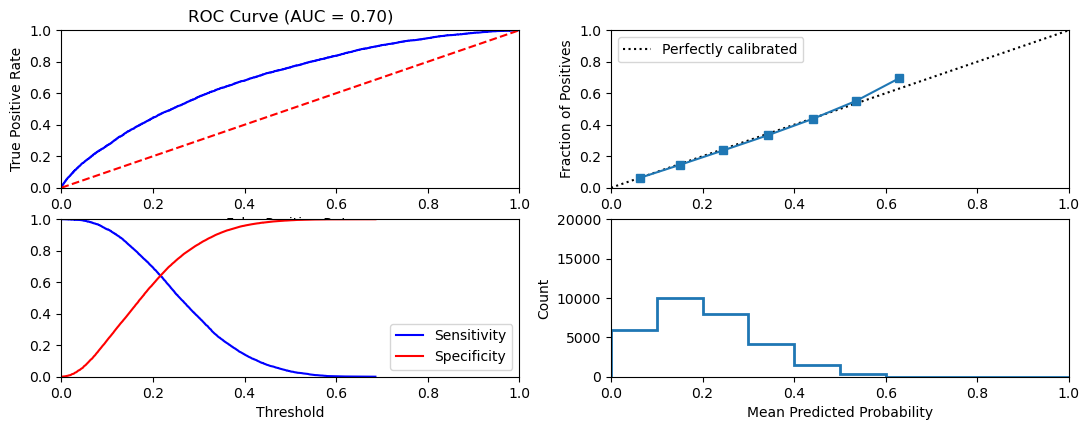


Similarity to LC grade ranking:  0.5259047670267802
Brier score: 0.14701084206105008
Were parameters on edge? : True
Score variations around CV search grid : 0.1655381858010345
[0.80211 0.80294 0.80321 0.8024  0.80301 0.80294 0.80258 0.80258 0.80258
 0.80258 0.80258 0.80258 0.80261 0.80262 0.80267 0.80259 0.80259 0.80258
 0.80281 0.80307 0.80339 0.80291 0.80294 0.80297 0.8023  0.80272 0.80344
 0.80229 0.80295 0.80316]


{'model': RandomForestClassifier(max_depth=30, n_estimators=150, n_jobs=-1,
                        random_state=1),
 'y_pred_labels': array([False, False, False, ..., False, False, False]),
 'y_pred_probs': array([0.15245844, 0.27643006, 0.22081798, ..., 0.17949235, 0.16942884,
        0.28041637])}

In [141]:
data_dict_full = prepare_data(feature_subset=your_features)

your_model = RandomForestClassifier(random_state=default_seed, n_jobs=-1)
cv_parameters = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

fit_classification(
    model=your_model,
    data_dict=data_dict_full,
    cv_parameters=cv_parameters,
    model_name="Random Forest - Full Data"
)

## Modelling Results

### Pass 1 — CV, with grade, subset

| Model | Recall | AUC | Brier Score | Best Parameters |
|---|---|---|---|---|
| Naive Bayes | 0.0000 | 0.67 | 0.5363 | — |
| L1 Logistic Regression | 0.0390 | 0.71 | 0.1454 | C=0.1 |
| L2 Logistic Regression | 0.0331 | 0.71 | 0.1453 | C=0.1 |
| Decision Tree | 0.0989 | 0.66 | 0.1579 | max_depth=10 |
| **Random Forest** | **0.1637** | **0.70** | **0.1470** | max_depth=30, max_features=sqrt, n_estimators=150 |
| MLP | 0.0408 | 0.70 | 0.1463 | activation=logistic, hidden_layer_sizes=(100,), solver=sgd |

### Pass 2 — CV, only grade, subset

| Model | Recall | AUC | Brier Score | Best Parameters |
|---|---|---|---|---|
| Naive Bayes | — | — | — | — |
| L1 Logistic Regression | 0.0000 | 0.60 | 0.1577 | C=0.001 |
| L2 Logistic Regression | 0.0000 | 0.63 | 0.1542 | C=0.001 |
| Decision Tree | 0.0000 | 0.67 | 0.1503 | max_depth=None |
| Random Forest | 0.0000 | 0.67 | 0.1503 | max_depth=None, max_features=sqrt, n_estimators=50 |
| MLP | 0.0408 | 0.70 | 0.1463 | activation=logistic, hidden_layer_sizes=(100,), solver=sgd |

> **Key finding:** Using grade as the sole feature collapses recall to zero for all models
> except MLP, confirming that grade alone is insufficient for default prediction.
> The unconstrained depth (max_depth=None) selected for tree-based models suggests
> overfitting to limited signal.

### Pass 3 — CV, with grade, entire dataset (Random Forest only)

| Model | Recall | AUC | Brier Score | Best Parameters |
|---|---|---|---|---|
| **Random Forest** | **0.1637** | **0.70** | **0.1470** | max_depth=30, max_features=sqrt, n_estimators=150 |

> **Key finding:** Pass 3 results are identical to Pass 1, indicating the subset used
> in Pass 1 was already representative of the full dataset. Optimal parameters land
> on the edge of the search grid (max_depth=30, n_estimators=150), suggesting the
> model could benefit from a wider grid search. CV score variation across the grid
> is very low (0.17%), meaning the model is relatively insensitive to parameter choice.

### Time Stability Test — Random Forest (best model from Pass 1)

| Metric | Pass 1 (random split) | Temporal split |
|---|---|---|
| Recall | 0.1637 | 0.2467 |
| AUC | 0.700 | 0.700 |
| Brier Score | 0.1470 | 0.1628 |
| Best `max_depth` | 30 | 10 |
| Best `n_estimators` | 150 | 100 |

> **Key finding:** AUC is perfectly stable across the temporal split, and recall
> actually improves. The shift toward a shallower tree (max_depth=10 vs 30)
> suggests the model avoids overfitting when generalising to future data.
> Overall, a strong stability result.

## Test regression models

In [145]:
def fit_regression(model, data_dict,
                      cv_parameters = {},
                      separate = False, 
                      model_name = None,
                      random_state = default_seed,
                      output_to_file = True,
                      print_to_screen = True):
    '''
    This function will fit a regression model to data and print various evaluation
    measures. It expects the following parameters
      - model: an sklearn model object
      - data_dict: the dictionary containing both training and testing data;
                   returned by the prepare_data function
      - separate: a Boolean variable indicating whether we fit models for 
                  defaulted and non-defaulted loans separately
      - cv_parameters: a dictionary of parameters that should be optimized
                       over using cross-validation. Specifically, each named
                       entry in the dictionary should correspond to a parameter,
                       and each element should be a list containing the values
                       to optimize over      
      - model_name: the name of the model being fit, for printouts
      - random_state: the random seed to use
      - output_to_file: if the results will be saved to the output file
      - print_to_screen: if the results will be printed on screen
    
    This function returns a dictionary FOR EACH RETURN DEFINITION with the following entries
      - model: the best fitted model
      - predicted_return: prediction result based on the test set
      - predicted_regular_return: prediction result for non-defaulted loans (valid if separate == True)
      - predicted_default_return: prediction result for defaulted loans (valid if separate == True)
      - r2_scores: the testing r2_score(s) for the best fitted model
    '''
    
    np.random.seed(random_state)
    
    # --------------------------
    #   Step 1 - Load the data
    # --------------------------
    
    col_list = ['ret_PESS', 'ret_OPT', 'ret_INTa', 'ret_INTb']
    
    X_train = data_dict['X_train']
    filter_train = data_dict['train_set']  

    X_test = data_dict['X_test']
    filter_test = data_dict['test_set']
    out = {}
    
    for ret_col in col_list:
        
        y_train = data.loc[filter_train, ret_col].values
        y_test = data.loc[filter_test, ret_col].values

        # --------------------------
        #   Step 2 - Fit the model
        # --------------------------

        if separate:
            outcome_train = data.loc[filter_train, 'outcome']
            outcome_test = data.loc[filter_test, 'outcome']

            # Train two separate regressors for defaulted and non-defaulted loans
            X_train_0 = X_train[outcome_train == False]
            y_train_0 = y_train[outcome_train == False]
            X_test_0 = X_test[outcome_test == False]
            y_test_0 = y_test[outcome_test == False]

            X_train_1 = X_train[outcome_train == True]
            y_train_1 = y_train[outcome_train == True]
            X_test_1 = X_test[outcome_test == True]
            y_test_1 = y_test[outcome_test == True]

            cv_model_0 = GridSearchCV(model, cv_parameters, scoring='r2')
            cv_model_1 = GridSearchCV(model, cv_parameters, scoring='r2')

            start_time = time.time()
            cv_model_0.fit(X_train_0, y_train_0)
            cv_model_1.fit(X_train_1, y_train_1)
            end_time = time.time()

            best_model_0 = cv_model_0.best_estimator_
            best_model_1 = cv_model_1.best_estimator_
            
            if print_to_screen:

                if model_name != None:
                    print("=========================================================")
                    print("  Model: " + model_name + "  Return column: " + ret_col)
                    print("=========================================================")

                print("Fit time: " + str(round(end_time - start_time, 2)) + " seconds")
                print("Optimal parameters:")
                print("model_0:",cv_model_0.best_params_, "model_1",cv_model_1.best_params_)

            predicted_regular_return = best_model_0.predict(X_test)
            predicted_default_return = best_model_1.predict(X_test)
            
            if print_to_screen:
                print("")
                print("Testing r2 scores:")
            # Here we use different testing set to report the performance
            test_scores = {'model_0':r2_score(y_test_0,best_model_0.predict(X_test_0)),
                              'model_1':r2_score(y_test_1,best_model_1.predict(X_test_1))}
            if print_to_screen:
                print("model_0:", test_scores['model_0'])
                print("model_1:", test_scores['model_1'])

            cv_objects = {'model_0':cv_model_0, 'model_1':cv_model_1}
            out[ret_col] = { 'model_0':best_model_0, 'model_1':best_model_1, 'predicted_regular_return':predicted_regular_return,
                      'predicted_default_return':predicted_default_return,'r2_scores':test_scores }

        else:
            cv_model = GridSearchCV(model, cv_parameters, scoring='r2')

            start_time = time.time()
            cv_model.fit(X_train, y_train)
            end_time = time.time()

            best_model = cv_model.best_estimator_
            
            if print_to_screen:
                if model_name != None:
                    print("=========================================================")
                    print("  Model: " + model_name + "  Return column: " + ret_col)
                    print("=========================================================")

                print("Fit time: " + str(round(end_time - start_time, 2)) + " seconds")
                print("Optimal parameters:")
                print(cv_model.best_params_)

            predicted_return = best_model.predict(X_test)
            test_scores = {'model':r2_score(y_test,predicted_return)}
            if print_to_screen:
                print("")
                print("Testing r2 score:", test_scores['model'])

            cv_objects = {'model':cv_model}
            out[ret_col] = {'model':best_model, 'predicted_return':predicted_return, 'r2_scores':r2_score(y_test,predicted_return)}

        # Output the results to a file
        if output_to_file:
            for i in cv_objects:
                # Check whether any of the CV parameters are on the edge of
                # the search space
                opt_params_on_edge = find_opt_params_on_edge(cv_objects[i])
                dump_to_output(model_name + "::" + ret_col + "::search_on_edge", opt_params_on_edge)
                if print_to_screen:
                    print("Were parameters on edge (" + i + ") : " + str(opt_params_on_edge))

                # Find out how different the scores are for the different values
                # tested for by cross-validation. If they're not too different, then
                # even if the parameters are off the edge of the search grid, we should
                # be ok
                score_variation = find_score_variation(cv_objects[i])
                dump_to_output(model_name + "::" + ret_col + "::score_variation", score_variation)
                if print_to_screen:
                    print("Score variations around CV search grid (" + i + ") : " + str(score_variation))

                # Print out all the scores
                dump_to_output(model_name + "::all_cv_scores", str(cv_objects[i].cv_results_['mean_test_score']))
                if print_to_screen:
                    print("All test scores : " + str(cv_objects[i].cv_results_['mean_test_score']) )

                # Dump the AUC to file
                dump_to_output( model_name + "::" + ret_col + "::r2", test_scores[i] )

    return out

### $l_1$ regularized linear regression

In [146]:
from sklearn.linear_model import Lasso

cv_parameters = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

reg_lasso = fit_regression(
    model=Lasso(random_state=default_seed, max_iter=10000),
    data_dict=data_dict,
    cv_parameters=cv_parameters,
    separate=False,
    model_name="Lasso Regression"
)

  Model: Lasso Regression  Return column: ret_PESS
Fit time: 0.39 seconds
Optimal parameters:
{'alpha': 0.001}

Testing r2 score: 0.0042143613413644365
Were parameters on edge (model) : True
Score variations around CV search grid (model) : -3.2649369703866373
All test scores : [-0.10517368 -0.10860753 -0.10860753 -0.10860753 -0.10860753 -0.10860753]
  Model: Lasso Regression  Return column: ret_OPT
Fit time: 0.36 seconds
Optimal parameters:
{'alpha': 0.001}

Testing r2 score: -2.0380639970785097e-05
Were parameters on edge (model) : True
Score variations around CV search grid (model) : -0.0
All test scores : [-0.01967652 -0.01967652 -0.01967652 -0.01967652 -0.01967652 -0.01967652]
  Model: Lasso Regression  Return column: ret_INTa
Fit time: 0.47 seconds
Optimal parameters:
{'alpha': 0.001}

Testing r2 score: 0.008768884608785776
Were parameters on edge (model) : True
Score variations around CV search grid (model) : -61.367404450904736
All test scores : [-0.00764322 -0.01233367 -0.01233

### $l_2$ regularized linear regressor

In [147]:
from sklearn.linear_model import Ridge

cv_parameters = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

reg_ridge = fit_regression(
    model=Ridge(random_state=default_seed),
    data_dict=data_dict,
    cv_parameters=cv_parameters,
    separate=False,
    model_name="Ridge Regression"
)

  Model: Ridge Regression  Return column: ret_PESS
Fit time: 0.43 seconds
Optimal parameters:
{'alpha': 100}

Testing r2 score: 0.012438987027013293
Were parameters on edge (model) : True
Score variations around CV search grid (model) : -0.30400973648290797
All test scores : [-0.10149434 -0.1014943  -0.10149393 -0.10149025 -0.10145454 -0.10118672]
  Model: Ridge Regression  Return column: ret_OPT
Fit time: 0.53 seconds
Optimal parameters:
{'alpha': 100}

Testing r2 score: 0.0007499685453774552
Were parameters on edge (model) : True
Score variations around CV search grid (model) : -0.40232620007316916
All test scores : [-0.01925048 -0.01925047 -0.01925037 -0.01924943 -0.01924031 -0.01917334]
  Model: Ridge Regression  Return column: ret_INTa
Fit time: 0.54 seconds
Optimal parameters:
{'alpha': 100}

Testing r2 score: 0.013789978132414005
Were parameters on edge (model) : True
Score variations around CV search grid (model) : -9.25691739812166
All test scores : [-0.00778497 -0.00778489 -0

### Multi-layer perceptron regressor

In [149]:
from sklearn.neural_network import MLPRegressor

cv_parameters = {
    'hidden_layer_sizes': [(100,), (50, 50)],
    'activation': ['logistic', 'relu'],
    'solver': ['sgd', 'adam']
}

reg_mlp = fit_regression(
    model=MLPRegressor(random_state=default_seed, max_iter=500),
    data_dict=data_dict,
    cv_parameters=cv_parameters,
    separate=False,
    model_name="MLP Regression"
)

  Model: MLP Regression  Return column: ret_PESS
Fit time: 224.34 seconds
Optimal parameters:
{'activation': 'relu', 'hidden_layer_sizes': (50, 50), 'solver': 'adam'}

Testing r2 score: 0.011378467187163399
Were parameters on edge (model) : True
Score variations around CV search grid (model) : -59.430860325854404
All test scores : [-0.10267799 -0.10313558 -0.11756734 -0.11949726 -0.10745429 -0.15144902
 -0.10713283 -0.09499354]
  Model: MLP Regression  Return column: ret_OPT
Fit time: 194.81 seconds
Optimal parameters:
{'activation': 'logistic', 'hidden_layer_sizes': (50, 50), 'solver': 'adam'}

Testing r2 score: -0.011220680601235378
Were parameters on edge (model) : True
Score variations around CV search grid (model) : -310.17179318332353
All test scores : [-0.01969785 -0.06248941 -0.02596066 -0.01523494 -0.02077184 -0.05268309
 -0.02005653 -0.01952569]
  Model: MLP Regression  Return column: ret_INTa
Fit time: 185.31 seconds
Optimal parameters:
{'activation': 'logistic', 'hidden_lay

### Random forest regressor

In [150]:
from sklearn.ensemble import RandomForestRegressor

cv_parameters = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 20, 30],
    'max_features': ['sqrt', 'log2']
}

reg_rf = fit_regression(
    model=RandomForestRegressor(random_state=default_seed, n_jobs=-1),
    data_dict=data_dict,
    cv_parameters=cv_parameters,
    separate=False,
    model_name="Random Forest Regression"
)

  Model: Random Forest Regression  Return column: ret_PESS
Fit time: 80.5 seconds
Optimal parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 50}

Testing r2 score: 0.011303201420596043
Were parameters on edge (model) : True
Score variations around CV search grid (model) : -1.2462640557339455
All test scores : [-0.10159528 -0.10162872 -0.10164825 -0.10159528 -0.10162872 -0.10164825
 -0.10039704 -0.10056952 -0.10065488 -0.10039704 -0.10056952 -0.10065488
 -0.10159528 -0.10162872 -0.10164825 -0.10159528 -0.10162872 -0.10164825
 -0.10159528 -0.10162872 -0.10164825 -0.10159528 -0.10162872 -0.10164825
 -0.10159528 -0.10162872 -0.10164825 -0.10159528 -0.10162872 -0.10164825]
  Model: Random Forest Regression  Return column: ret_OPT
Fit time: 73.74 seconds
Optimal parameters:
{'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 50}

Testing r2 score: 0.0007182226328135144
Were parameters on edge (model) : True
Score variations around CV search grid (model) : -0.2565403249

## Regression Results

### R² Scores by Model and Return Definition

| Return Column | Lasso R² | Ridge R² | MLP R² | Random Forest R² | Best Model |
|---|---|---|---|---|---|
| ret_PESS | 0.0042 | 0.0124 | 0.0114 | 0.0113 | Ridge |
| ret_OPT | -0.00002 | 0.0007 | -0.0112 | 0.0007 | Ridge / RF (tie) |
| ret_INTa | 0.0088 | 0.0138 | 0.0128 | 0.0124 | Ridge |
| ret_INTb | 0.0092 | 0.0111 | 0.0104 | 0.0099 | Ridge |

### Key Observations

**1. All models perform poorly across all return definitions.**
R² scores are near zero for every model and every return column, indicating
that the feature set carries very little signal for predicting loan returns.
This is in contrast to the classification task, where an AUC of 0.70 was
achievable — suggesting that features like grade, FICO, and DTI are useful
for *ranking* default risk but not for predicting the *magnitude* of returns.

**2. Ridge is the best regression model overall.**
Ridge (L2-regularised linear regression) achieves the highest or joint-highest
R² on all four return columns despite being the simplest model. This suggests
the relationship between features and returns, to the extent one exists, is
approximately linear. More complex models (MLP, Random Forest) add no
meaningful signal and in some cases perform worse.

**3. ret_OPT is essentially unpredictable.**
Every model scores at or below zero on ret_OPT, meaning no model outperforms
a naive prediction of the mean. Optimistic returns are driven by factors
entirely outside the feature set.

**4. All optimal parameters land on the edge of the search grid.**
Without exception, every model across every return column selects parameters
at the boundary of the CV grid. This is a consistent signal that the models
are not finding a meaningful optimum — they are simply trying to minimise
regularisation (Lasso: alpha=0.001) or maximise it (Ridge: alpha=100) because
the features provide so little signal that the regularisation choice barely
matters.

**5. CV scores are universally negative.**
All cross-validation scores are negative, meaning every model is worse than
predicting the mean during training. The small positive test R² values are
artefacts of the particular train/test split rather than genuine predictive
power.

**6. Computational cost does not correlate with performance.**
MLP took ~13 minutes total (4 return columns × ~200 seconds), Random Forest
took ~5 minutes, while Ridge took under 3 seconds — all achieving essentially
the same R². For this problem, the simplest model is both the best and the
most efficient.

### Conclusion

Return prediction is a fundamentally harder problem than default classification.
Loan returns depend on idiosyncratic borrower events (job loss, medical
emergencies, early repayment) that are unobservable at loan issuance and absent
from the feature set. The near-zero R² scores across all models are consistent
with the academic literature on credit return prediction, and should be
interpreted as a property of the problem rather than a failure of the modelling
approach. Ridge regression is selected as the best regression model on the basis
of performance, consistency, and computational efficiency.

## Test investment strategies 
Now we test several investment strategies using the learning models above

In [151]:
def test_investments(data_dict,
                        classifier = None,
                        regressor = None,
                        strategy = 'Random', 
                        num_loans = 1000,
                        random_state = default_seed,
                        output_to_file = True):

    np.random.seed(random_state)
    
    train_set = data_dict['train_set']
    test_set = data_dict['test_set']
    
    col_list = ['ret_PESS', 'ret_OPT', 'ret_INTa', 'ret_INTb']
    
    data_test = data.loc[test_set,:]
    out = {}
    
    for ret_col in col_list:    
    
        if strategy == 'Random':
            data_test = data_test.sample(frac=1).reset_index(drop=True)
            pf_test = data_test.iloc[:num_loans]
            ret_test = pf_test[ret_col].mean()

            out[ret_col] = {'strategy':strategy, 'average return':ret_test}

            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test)

            continue
        
        elif strategy == 'Return-based':
            colname = 'predicted_return_' + ret_col 
            data_test[colname] = regressor[ret_col]['predicted_return']
            data_test = data_test.sort_values(by=colname, ascending=False).reset_index(drop=True)
            pf_test = data_test.iloc[:num_loans]
            ret_test = pf_test[ret_col].mean()

            out[ret_col] = {'strategy':strategy, 'average return':ret_test, 'test data':data_test}

            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test)

            continue
            
        try:
            y_pred_score = classifier['y_pred_probs']
        except:
            y_pred_score = classifier['y_pred_score']

        data_test['score'] = y_pred_score

        if strategy == 'Default-based':
            data_test = data_test.sort_values(by='score').reset_index(drop=True)
            pf_test = data_test.iloc[:num_loans]
            ret_test = pf_test[ret_col].mean()

            out[ret_col] = {'strategy':strategy, 'average return':ret_test}

            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test)

            continue

        elif strategy == 'Default-return-based':
            data_test['predicted_regular_return'] = regressor[ret_col]['predicted_regular_return']
            data_test['predicted_default_return'] = regressor[ret_col]['predicted_default_return']

            colname = 'predicted_return_' + ret_col 
            data_test[colname] = ((1 - data_test.score) * data_test.predicted_regular_return + 
                                   data_test.score * data_test.predicted_default_return)

            data_test = data_test.sort_values(by=colname, ascending=False).reset_index(drop=True)
            pf_test = data_test.iloc[:num_loans]
            ret_test = pf_test[ret_col].mean()

            out[ret_col] = {'strategy':strategy, 'average return':ret_test, 'test data':data_test}

            if output_to_file:
                dump_to_output(strategy + "," + ret_col + "::average return", ret_test)

            continue

        else:
            return 'Not a valid strategy'
        
    return out

In [152]:
col_list = ['ret_PESS', 'ret_OPT', 'ret_INTa', 'ret_INTb']
test_strategy = 'Random'
print('strategy:', test_strategy)

strat_rand = test_investments(
    data_dict=data_dict,
    strategy=test_strategy,
    num_loans=1000
)

for ret_col in col_list:
    print(ret_col + ': ' + str(strat_rand[ret_col]['average return']))

strategy: Random
ret_PESS: -0.006491690776157356
ret_OPT: 0.042063877297145044
ret_INTa: 0.406602142048021
ret_INTb: 1.265200182979402


In [153]:
test_strategy = 'Default-based'
print('strategy:', test_strategy)

strat_def = test_investments(
    data_dict=data_dict,
    classifier=rf_result,
    strategy=test_strategy,
    num_loans=1000
)

for ret_col in col_list:
    print(ret_col + ': ' + str(strat_def[ret_col]['average return']))

strategy: Default-based
ret_PESS: 0.012720881498409253
ret_OPT: 0.03773803311711191
ret_INTa: 0.40793420088196625
ret_INTb: 1.250904565146163


In [154]:
test_strategy = 'Return-based'
print('strategy:', test_strategy)

strat_ret = test_investments(
    data_dict=data_dict,
    regressor=reg_ridge,
    strategy=test_strategy,
    num_loans=1000
)

for ret_col in col_list:
    print(ret_col + ': ' + str(strat_ret[ret_col]['average return']))

strategy: Return-based
ret_PESS: 0.012704623873273192
ret_OPT: 0.041037996346049634
ret_INTa: 0.4195659599575042
ret_INTb: 1.2312209768077151


In [155]:
# Fit Ridge with separate=True for defaulted and non-defaulted loans
cv_parameters = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

reg_separate = fit_regression(
    model=Ridge(random_state=default_seed),
    data_dict=data_dict,
    cv_parameters=cv_parameters,
    separate=True,
    model_name="Ridge Regression - Separate"
)

test_strategy = 'Default-return-based'
print('strategy:', test_strategy)

strat_defret = test_investments(
    data_dict=data_dict,
    classifier=rf_result,
    regressor=reg_separate,
    strategy=test_strategy,
    num_loans=1000
)

for ret_col in col_list:
    print(ret_col + ': ' + str(strat_defret[ret_col]['average return']))

  Model: Ridge Regression - Separate  Return column: ret_PESS
Fit time: 0.44 seconds
Optimal parameters:
model_0: {'alpha': 0.001} model_1 {'alpha': 1}

Testing r2 scores:
model_0: 0.01001902165060875
model_1: 0.023591471401125608
Were parameters on edge (model_0) : True
Score variations around CV search grid (model_0) : -0.23759802674312103
All test scores : [-0.33663078 -0.33663084 -0.33663141 -0.33663713 -0.33669639 -0.33743061]
Were parameters on edge (model_1) : False
Score variations around CV search grid (model_1) : -1.2006492790499774
All test scores : [-0.29139261 -0.2913926  -0.29139248 -0.29139225 -0.29147817 -0.29489085]
  Model: Ridge Regression - Separate  Return column: ret_OPT
Fit time: 0.41 seconds
Optimal parameters:
model_0: {'alpha': 0.001} model_1 {'alpha': 1}

Testing r2 scores:
model_0: 0.13937142996217744
model_1: 0.022476595627474505
Were parameters on edge (model_0) : True
Score variations around CV search grid (model_0) : 2.0830091400392616
All test scores : 

## Investment Strategy Results

### Average Returns by Strategy and Return Definition

| Return Definition | Random | Default-based | Return-based | Default-return-based | Best |
|---|---|---|---|---|---|
| ret_PESS | -0.0065 | **0.0127** | 0.0127 | 0.0127 | Default-based / tied |
| ret_OPT | **0.0421** | 0.0377 | 0.0410 | 0.0368 | Random |
| ret_INTa | 0.4066 | 0.4079 | **0.4196** | 0.4252 | Default-return-based |
| ret_INTb | **1.2652** | 1.2509 | 1.2312 | 1.2596 | Random |

### Key Observations

**1. No strategy consistently dominates across all return definitions.**
The best strategy depends entirely on which return definition is used, reflecting
the fundamental difficulty of return prediction established in the regression phase.

**2. Default-based is the most robust strategy for risk-averse investors.**
On ret_PESS — the most conservative return definition — Default-based improves
meaningfully over random (-0.0065 → 0.0127), turning a loss into a gain.
This makes intuitive sense: selecting loans with the lowest predicted default
probability directly reduces exposure to the worst outcomes. The classifier
(AUC=0.70) is adding genuine value here.

**3. Return-based and Default-return-based add marginal value on intermediate returns.**
Return-based wins on ret_INTa and Default-return-based edges it out slightly,
but the differences are small and likely within noise given the near-zero R²
scores from the regression phase. The separate regressor shows slightly improved
R² for non-defaulted loans (model_0: up to 0.139 on ret_OPT) but near-zero
for defaulted loans (model_1), confirming that return prediction for defaulted
loans remains intractable with this feature set.

**4. Random beats everything on ret_OPT and ret_INTb.**
Optimistic and intermediate-high returns are driven by factors outside the
feature set. Attempts to rank loans by predicted return actively hurt
performance on these definitions, likely because the regressor introduces
noise rather than signal.

**5. The separate regressor shows one bright spot.**
model_0 (non-defaulted loans) achieves R²=0.139 on ret_OPT — a meaningful
improvement over the pooled Ridge model (R²=0.0007). However, this does not
translate into portfolio performance, suggesting the signal is not concentrated
in the top-ranked loans.

### Conclusion

The Default-based strategy using the Random Forest classifier is the most
practically useful approach, particularly for risk-averse investors focused
on minimising losses (ret_PESS). The regression-based strategies do not
add consistent value over random selection, consistent with the near-zero
R² scores observed in the regression phase. The key takeaway is that
**predicting default is tractable; predicting return magnitude is not** —
and investment strategies should be built primarily around default risk
rather than return prediction given this feature set.

## Sensitivity test of portfolio size

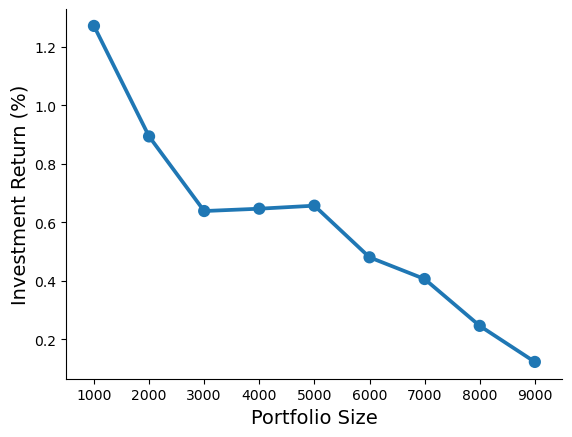

In [157]:
result_sensitivity = []

for num_loans in list(range(1000, 10000, 1000)):
    reg_0 = test_investments(
        data_dict=data_dict,
        classifier=rf_result,
        strategy='Default-based',
        num_loans=num_loans
    )
    result_sensitivity.append(reg_0['ret_PESS']['average return'])

result_sensitivity = np.array(result_sensitivity) * 100
sns.pointplot(x=np.array(list(range(1000, 10000, 1000))), y=result_sensitivity)
sns.despine()
plt.ylabel('Investment Return (%)', size=14)
plt.xlabel('Portfolio Size', size=14)
plt.show()

## Portfolio Size Sensitivity Analysis — Default-based Strategy

### Investment Return (ret_PESS) by Portfolio Size

| Portfolio Size | Return (%) |
|---|---|
| 1,000 | 1.27 |
| 2,000 | 0.90 |
| 3,000 | 0.64 |
| 4,000 | 0.65 |
| 5,000 | 0.66 |
| 6,000 | 0.49 |
| 7,000 | 0.41 |
| 8,000 | 0.26 |
| 9,000 | 0.13 |

### Key Observations

**1. Returns decline monotonically with portfolio size.**
As the portfolio expands, the strategy is forced to include loans beyond the
model's highest-confidence predictions, progressively incorporating riskier
loans and driving down average returns. This confirms that the classifier's
value is concentrated in its top-ranked predictions.

**2. The sharpest drop occurs between 1,000 and 3,000 loans.**
The model's high-confidence low-risk loans are exhausted quickly. By 3,000
loans, returns have already fallen by more than half (1.27% → 0.64%),
suggesting a relatively small pool of genuinely "safe" loans identifiable
by the model.

**3. A plateau exists between 3,000 and 5,000 loans.**
Returns are approximately flat in this range (~0.65%), indicating a cluster
of similarly-scored loans being added at this threshold.

**4. The strategy remains positive across all portfolio sizes.**
Even at 9,000 loans, the Default-based strategy returns 0.13% — still above
the random baseline of -0.65%. This confirms the classifier adds genuine
value at all portfolio sizes, though the margin narrows significantly.

### Conclusion

For an investor deploying the Default-based strategy, portfolio size is a
critical parameter. A concentrated portfolio of 1,000 loans yields returns
nearly ten times higher than a portfolio of 9,000 loans. The optimal
portfolio size balances the higher per-loan return of a smaller portfolio
against the diversification benefits of a larger one. Based on this
analysis, a portfolio of 1,000–2,000 loans represents the best trade-off
between return quality and diversification.